### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [29]:
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/BreastCancerWisconsin.csv')

In [5]:
df.shape

(569, 33)

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Step 3: Exploring Data

Basic Info

In [7]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

Feature Distribution

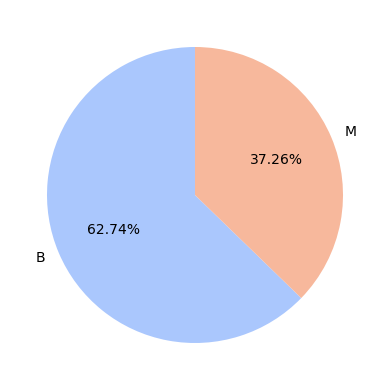

In [10]:
plt.figure(figsize=(4, 4))
plt.pie(
    df['diagnosis'].value_counts(),
    autopct='%.2f%%',
    colors=sns.color_palette('coolwarm', 2),
    startangle=90,
    labels=df['diagnosis'].value_counts().index
)
plt.tight_layout()

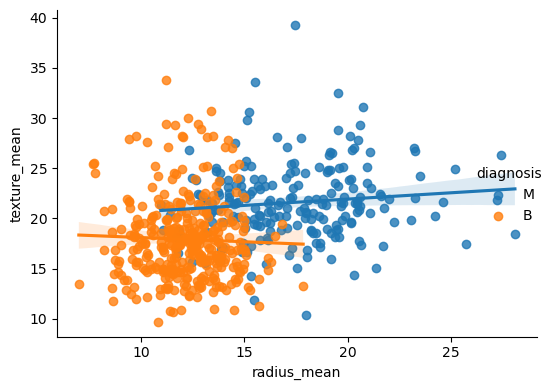

In [11]:
sns.lmplot(
    x='radius_mean', 
    y='texture_mean',
    hue='diagnosis',
    data=df,
    height=4,
    aspect=1.2
)
plt.tight_layout()

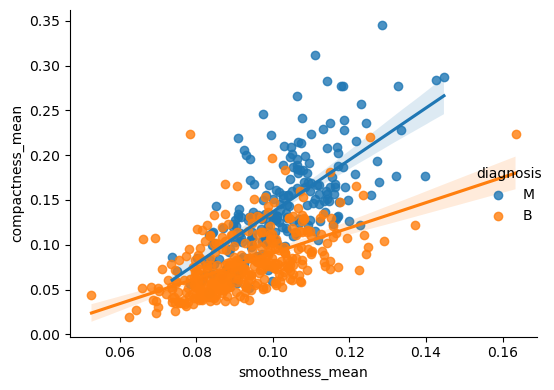

In [12]:
sns.lmplot(
    x='smoothness_mean', 
    y='compactness_mean',
    hue='diagnosis',
    data = df,
    height=4,
    aspect=1.2
)
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [13]:
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

Normalization

In [17]:
num_cols = df.select_dtypes(np.number).columns

In [19]:
scaler = StandardScaler()

In [20]:
for col in num_cols:
    df[col] = scaler.fit_transform(df[[col]])

Feature Encoding

In [21]:
obj_cols = df.select_dtypes(np.object_).columns

In [23]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

### Step 5: Preparing Data

Select Features

In [47]:
features = df.drop('diagnosis', axis=1)
target = df['diagnosis']

In [48]:
selector = SmartCorrelatedSelection(
    threshold=0.8,
    selection_method='corr_with_target'
)

In [49]:
features = selector.fit_transform(features, target)
print(f'Current number of features: {features.shape[1]}')

Current number of features: 14


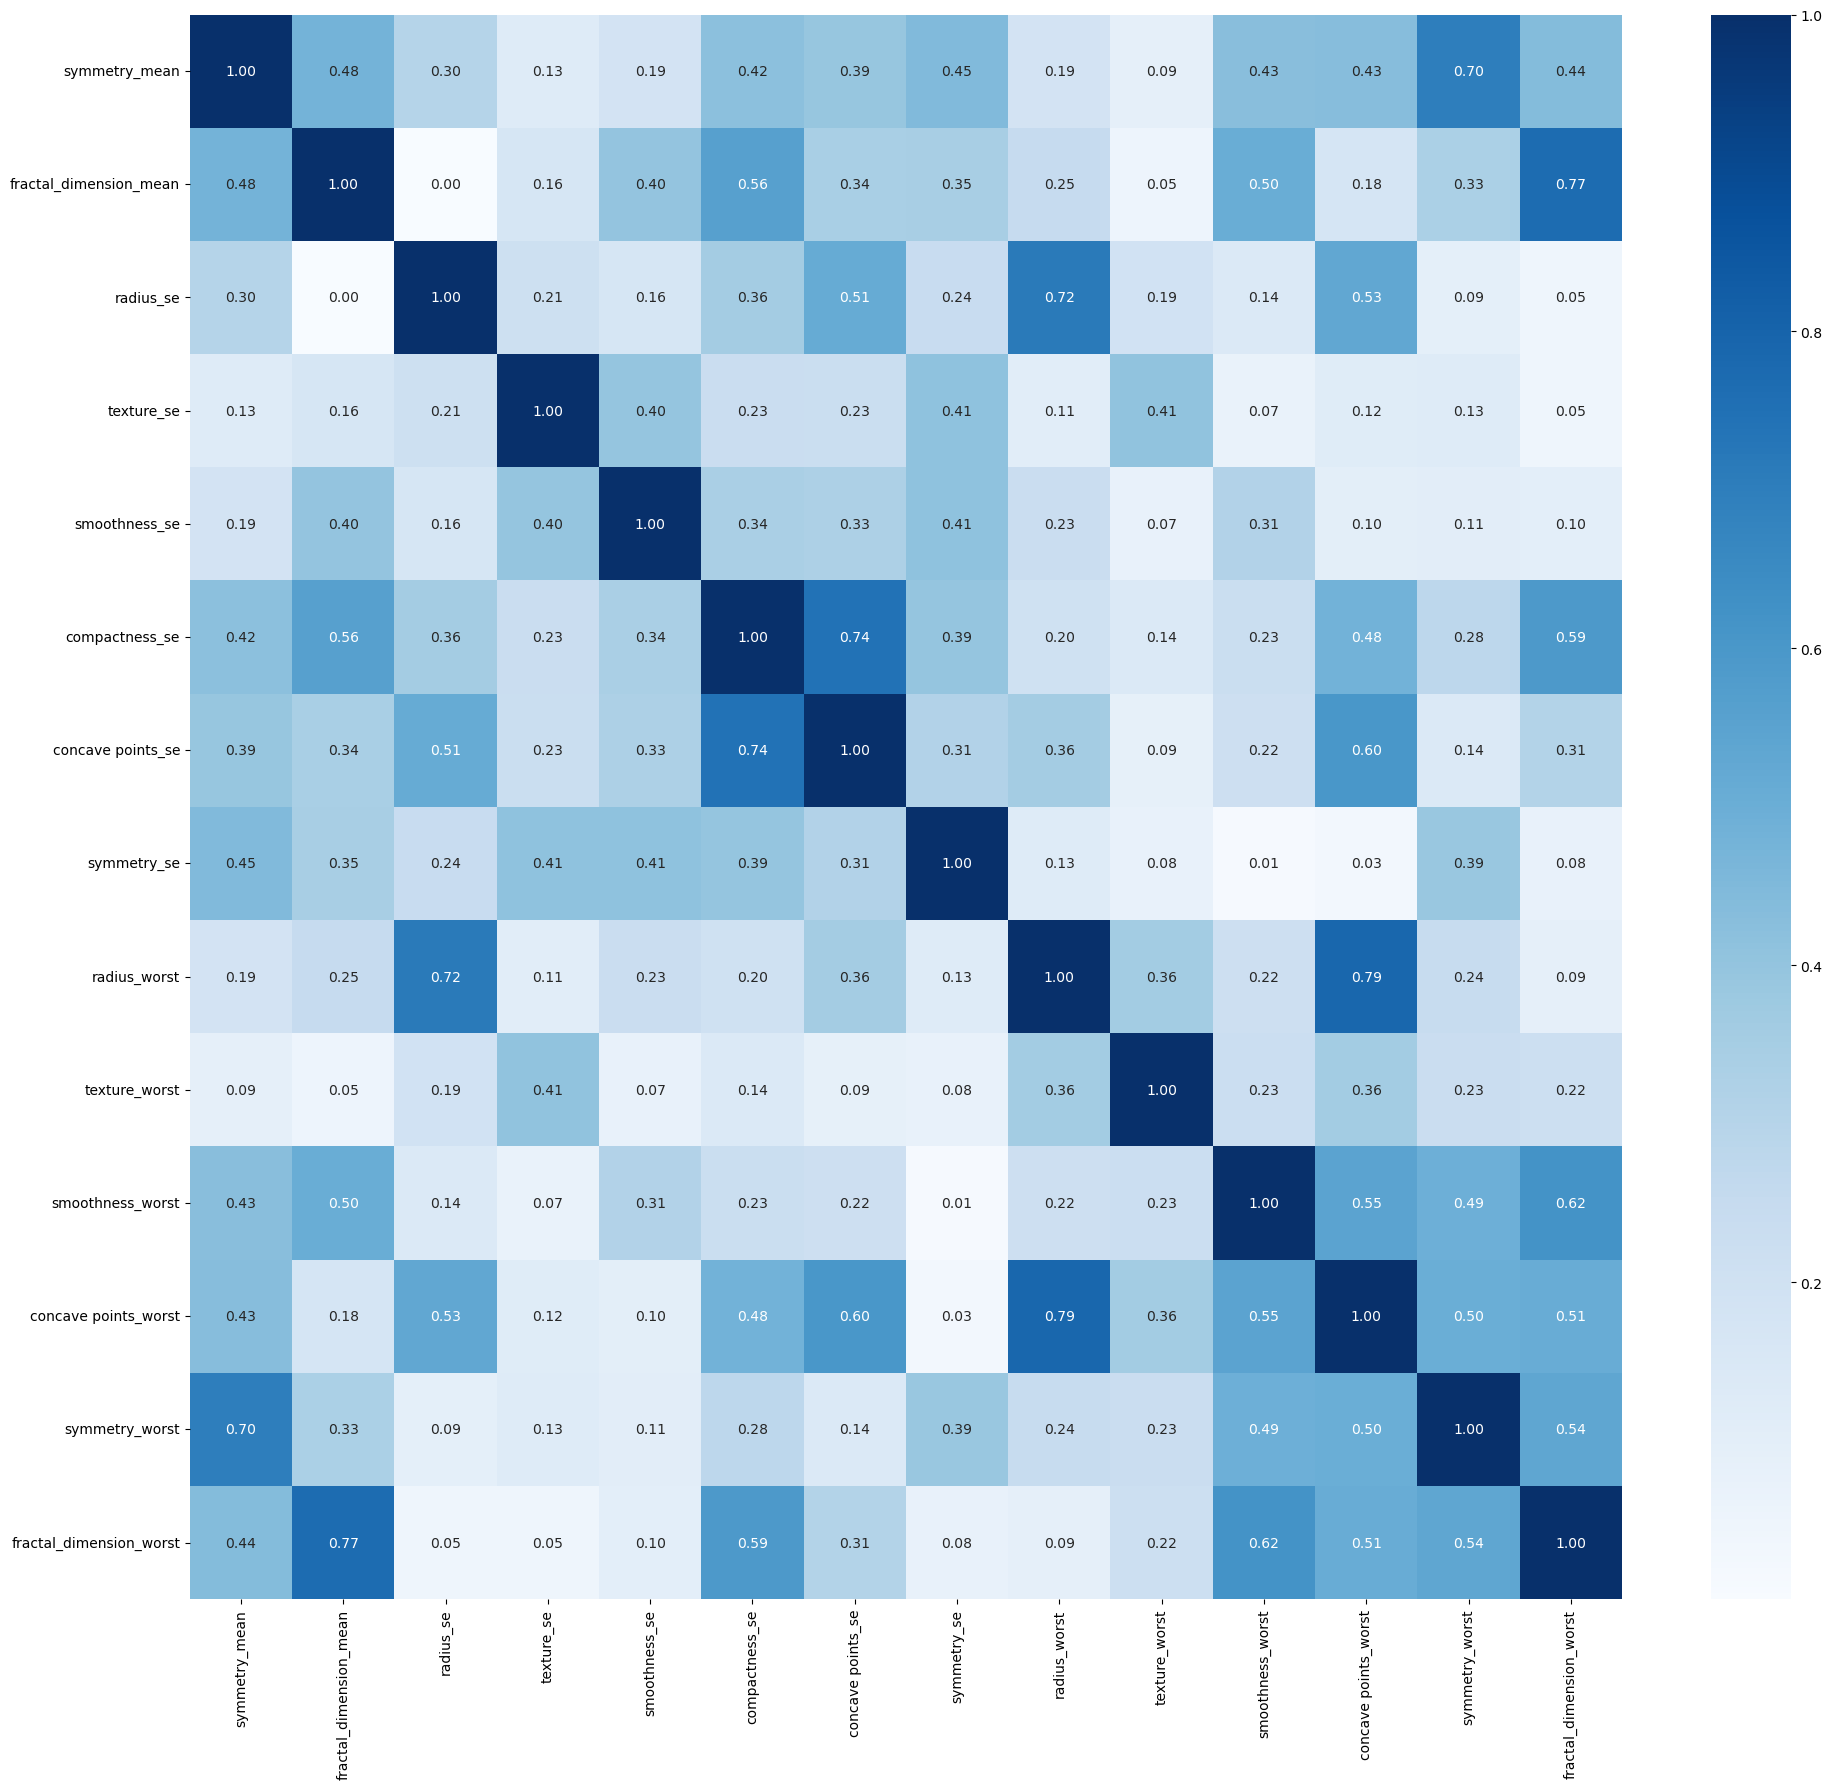

In [51]:
plt.figure(figsize=(20, 18))
sns.heatmap(
    features.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

Split Data

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Balanced Data

In [54]:
ros = RandomOverSampler(random_state=42)

In [55]:
X_train, y_train = ros.fit_resample(X_train, y_train)

### Step 6: Building & Training Model

In [155]:
model = KNeighborsClassifier(n_neighbors=1)

In [156]:
strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [157]:
scores = cross_val_score(
    model, 
    X_train,
    y_train,
    cv=strat,
    scoring='accuracy',
    n_jobs=-1,
    error_score='raise'
)

In [158]:
print(f'Model: {model.__class__.__name__}')
print(f'Scores: {list(map(lambda x: round(x, 3), scores))}')
print(f'Mean Accuracy: {scores.mean():.3f}')

Model: KNeighborsClassifier
Scores: [0.983, 0.948, 0.965, 0.974, 0.974]
Mean Accuracy: 0.969


In [159]:
model.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Step 7: Evaluate Model

In [160]:
y_pred = model.predict(X_test)

Accuracy

In [161]:
accuracy = metrics.accuracy_score(y_test, y_pred)

In [162]:
print(f'Accuracy of the model is {100 * accuracy:.3f}%')

Accuracy of the model is 93.860%


In [163]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



Confusion Matrix

In [164]:
cm = metrics.confusion_matrix(y_test, y_pred)

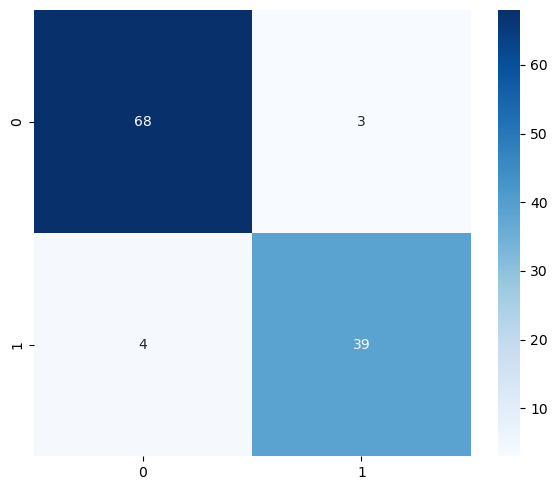

In [165]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    fmt='d',
    cmap=plt.cm.Blues,
    annot=True
)
plt.tight_layout()

### Step 8: Misclassification Error Versus k

In [166]:
neighbors, cv_scores = list(), list()

In [167]:
for k in range(1, 53, 2):
    neighbors.append(k)
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=strat,
        scoring='accuracy'
    )
    cv_scores.append(scores.mean())

In [168]:
MSE = [1-x for x in cv_scores]

In [169]:
optimal_k = neighbors[MSE.index(min(MSE))]

In [170]:
print('The optimal number of neighbors is % d ' % optimal_k)

The optimal number of neighbors is  1 


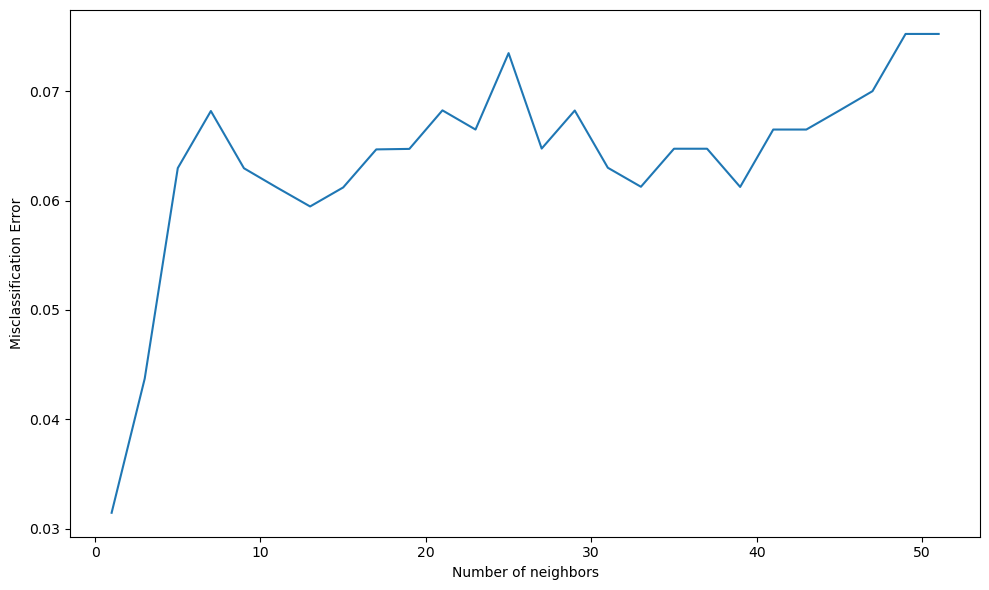

In [171]:
plt.figure(figsize = (10, 6))
plt.plot(neighbors, MSE)
plt.xlabel('Number of neighbors')
plt.ylabel('Misclassification Error')
plt.tight_layout()